# 05. 畳み込み・インパルス応答・伝達関数 — 入力を出力に変える

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> 時間の畳み込み = $s$ の積。インパルス応答 $h$ と伝達関数 $H$ が LTI 系を完全に決める。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets, discrete
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture

線形時不変(LTI)な系は、たった1つの関数 **インパルス応答 $h(t)$**(または **伝達関数 $H(s)$**)で
完全に決まります。任意入力 $x$ への出力は

$$ y(t) = (h * x)(t) \quad\Longleftrightarrow\quad Y(s) = H(s)\,X(s). $$

**時間では畳み込み、$s$ では掛け算**。これが本章の主題です。

## 2. Problem / 3. Intuition — 畳み込みとは

畳み込み

$$ (f * g)(t) = \int_0^t f(\tau)\,g(t-\tau)\,d\tau $$

は「入力を少しずつ流し込み、過去の影響が尾を引きながら混ざる」操作。直感的には難しいのに、
$s$ 領域に移すと **ただの掛け算** $F(s)G(s)$ になります(畳み込み定理)。

## 4. Visualization — 時間の畳み込み

入力パルス $f$ とインパルス応答 $g(t)=e^{-2t}$ の畳み込みを描きます。

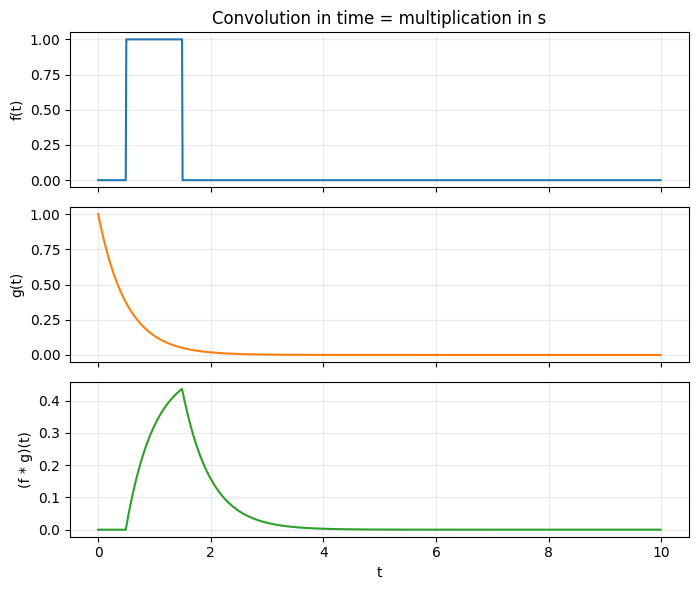

In [2]:
dt = 0.01
tt = np.arange(0, 10, dt)
f = datasets.unit_step(tt, 0.5) - datasets.unit_step(tt, 1.5)   # a rectangular pulse
g = np.exp(-2 * tt)                                             # exponential response
conv = systems.convolve(f, g, dt)
plotting.plot_convolution(tt, f, g, conv)
plt.tight_layout()

## 4b. 畳み込みのアニメーション (Applied)

畳み込みの定番の見方:応答 $g$ を **反転して滑らせ**、各 $t$ での重なり(積 $f(\tau)g(t-\tau)$ の面積)が
$(f*g)(t)$。下段にその出力が描かれていく。

In [3]:
from IPython.display import HTML

dt = 0.05
tt = np.arange(0, 9, dt)
f = datasets.unit_step(tt, 0.5) - datasets.unit_step(tt, 1.5)   # rectangular pulse
g = np.exp(-2 * tt)                                             # exponential response
anim = plotting.animate_convolution(f, g, tt)
html = anim.to_jshtml(fps=8)
plt.close("all")
HTML(html)

## 5. Definition / 6. Computation — 畳み込み定理を確かめる

$f=e^{-t},\ g=e^{-2t}$。畳み込み定理より $\mathcal{L}\{f*g\}=\dfrac{1}{(s+1)(s+2)}$、
よって $(f*g)(t)=e^{-t}-e^{-2t}$。時間で直接畳み込んだ結果と一致するはずです。

max |time-domain conv - s-domain product| = 0.005


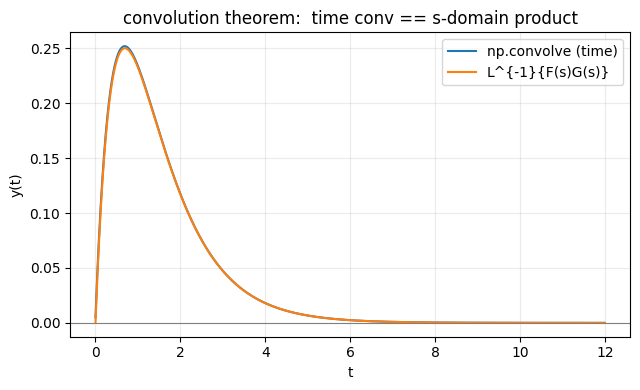

In [4]:
dt = 0.005
tt = np.arange(0, 12, dt)
conv_time = systems.convolve(np.exp(-tt), np.exp(-2 * tt), dt)     # time-domain

F, G = 1 / (s + 1), 1 / (s + 2)
prod = sp.apart(F * G, s)
display(prod)                                                      # 1/(s+1) - 1/(s+2)
conv_s = transforms.as_function(Linv(F * G))(tt)                   # via s-domain product

print("max |time-domain conv - s-domain product| =", np.max(np.abs(conv_time - conv_s)))
plotting.plot_time_responses(tt, [conv_time, conv_s],
                             labels=["np.convolve (time)", "L^{-1}{F(s)G(s)}"],
                             title="convolution theorem:  time conv == s-domain product")
plt.tight_layout()

## 7. Invariant / Structure — インパルス応答と伝達関数

$x(t)=\delta(t)$ を入れると $X(s)=1$ なので $Y(s)=H(s)$。逆変換した $h(t)=\mathcal{L}^{-1}\{H\}$ が
**インパルス応答**。これが系の「指紋」で、任意入力の出力は $h$ との畳み込みで出ます。下で
「`lsim` による出力」と「インパルス応答との畳み込み」が一致することを確かめます。

max |lsim - (h * u)| = 0.01


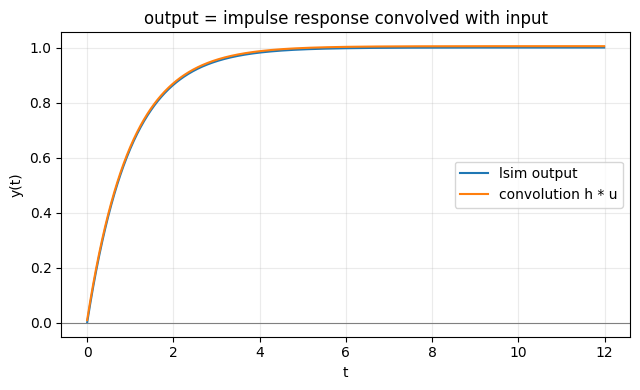

In [5]:
dt = 0.01
tt = np.arange(0, 12, dt)
sys = systems.first_order(tau=1.0)            # H(s) = 1/(s+1)
h = systems.impulse_response(sys, tt)         # h(t) = e^{-t}
u = np.ones_like(tt)                          # unit step input

y_lsim = systems.forced_response(sys, u, tt)  # output via state-space simulation
y_conv = systems.convolve(u, h, dt)           # output via convolution with h

print("max |lsim - (h * u)| =", np.max(np.abs(y_lsim - y_conv)))
plotting.plot_time_responses(tt, [y_lsim, y_conv],
                             labels=["lsim output", "convolution h * u"],
                             title="output = impulse response convolved with input")
plt.tight_layout()

## 8. 伝達関数 H(s) = Y(s)/X(s)

ステップ入力 $X(s)=1/s$ を $H(s)=1/(s+1)$ に通すと $Y=\dfrac{1}{s(s+1)}\to y=1-e^{-t}$。
入力(像)に伝達関数を掛けて逆変換、というのが LTI 系の基本動作です。

In [6]:
H = 1 / (s + 1)
X = 1 / s                      # unit step
Y = H * X
display(Linv(Y))               # 1 - e^{-t}

## 9. Application / 10. Failure Mode

- **応用**: フィルタ(平滑化 = 低域通過)、残響(エコー = 畳み込み)、系の同定(入出力から $H$ を推定)。
- **注意**: 畳み込み定理は **LTI かつ因果・初期静止** が前提。非線形系や時変系では成り立たない。

## 11. Exercises / Advanced

- **Basic**: $H=1/(s+2)$ のインパルス応答とステップ応答を求めよ。
- **Applied**: 2つの1次系の直列 $H_1H_2$ のインパルス応答を畳み込みで作り、`systems.series` と比べよ。
- **Advanced**: LTI 性(線形 + 時不変)から、出力が必ず畳み込みで書けることを示せ。